In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')

In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,family_type
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1,Small
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2,Small
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1,Small
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1,Small
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,1,Small
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1,Small
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1,Small
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,1,Small


In [9]:
def family_filter(x):
    if x<=3:
        return 'Small'
    elif x>3 and x<5:
        return 'Medium'
    else:
        return 'Large'
        

In [4]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1

In [7]:
df['family_type'] = df['family_size'].apply(
    lambda x: 'Small' if x <=3 else 'Large'
)

In [10]:
df['family_type'] = df['family_size'].apply(
    family_filter
)

<Axes: xlabel='family_size', ylabel='Survived'>

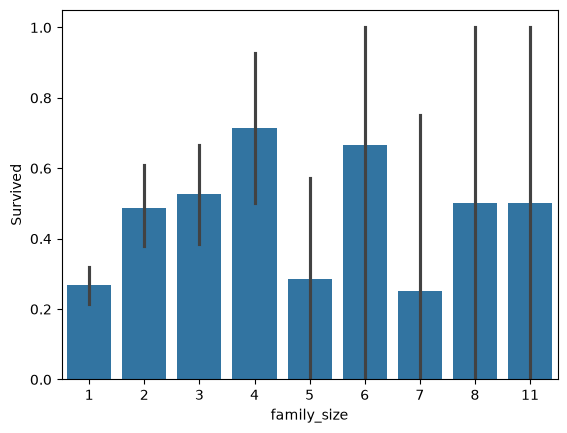

In [13]:
sns.barplot(data=df, x='family_size', y='Survived')

In [14]:
df['family_size'].value_counts()

family_size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [15]:
df['family_type'].value_counts()

family_type
Small     384
Large      20
Medium     14
Name: count, dtype: int64

In [16]:
pd.crosstab(df['family_type'], df['Survived'])

Survived,0,1
family_type,,
Large,12,8
Medium,4,10
Small,250,134


In [18]:
df['Actual Fare'] = df['Fare'] / df['family_size']

In [33]:
df['Name'].str.split(',').str[1].str.split('.').str[0]

0           Mr
1          Mrs
2           Mr
3           Mr
4          Mrs
        ...   
413         Mr
414       Dona
415         Mr
416         Mr
417     Master
Name: Name, Length: 418, dtype: object

In [39]:
df['Name'].str.split(',')

0                                  [Kelly,  Mr. James]
1                  [Wilkes,  Mrs. James (Ellen Needs)]
2                         [Myles,  Mr. Thomas Francis]
3                                  [Wirz,  Mr. Albert]
4      [Hirvonen,  Mrs. Alexander (Helga E Lindqvist)]
                            ...                       
413                              [Spector,  Mr. Woolf]
414                    [Oliva y Ocana,  Dona. Fermina]
415                    [Saether,  Mr. Simon Sivertsen]
416                             [Ware,  Mr. Frederick]
417                        [Peter,  Master. Michael J]
Name: Name, Length: 418, dtype: object

In [43]:
df['Name'].str.split(',').str[1].str.split('.').str[0]

0           Mr
1          Mrs
2           Mr
3           Mr
4          Mrs
        ...   
413         Mr
414       Dona
415         Mr
416         Mr
417     Master
Name: Name, Length: 418, dtype: object